
Best objective: 2784 (Deterministic ArborEnum
-----------------------
elapsed seconds: 6.95
minimum objective: 2784
number of trees: 44
0.160193)
Objective bound: 2812
Minimum objective: 2784
Cache sizes - Greedy: 364104, Lickety: 6373, Trie: 61, Trie cache: ON
Extending anytime multiplier to 
Anytime ArborEnum
-----------------
elapsed seconds: 22.07
minimum objective: 2784
number of trees found in total: 7664
trees within a 0.01 multiplier of the best tree found: 44
trees within a 0.03 multiplier of the best tree found: 7664
0.0125 with objective bound 2819
Extended minimum objective: 2784
Extending anytime multiplier to 0.015 with objective bound 2826
Extended minimum objective: 2784
Extending anytime multiplier to 0.0175 with objective bound 2833
Extended minimum objective: 2784
Extending anytime multiplier to 0.02 with objective bound 2840
Extended minimum objective: 2784
Extending anytime multiplier to 0.0225 with objective bound 2847
Extended minimum objective: 2784
Extending a

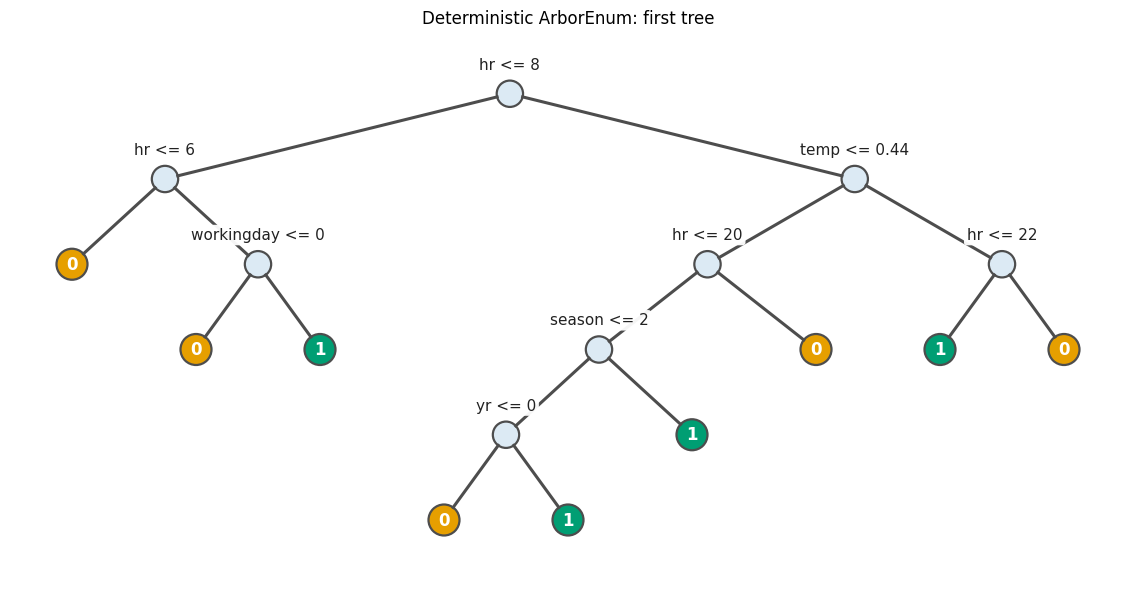


Deterministic ArborEnum: last tree
----------------------------------------
tree index: 43
objective: 2811
normalized objective: 0.16174693595718972
number of leaves: 10
accuracy: 0.888313
first 10 predictions: [1, 0, 0, 0, 1, 1, 1, 0, 1, 1]


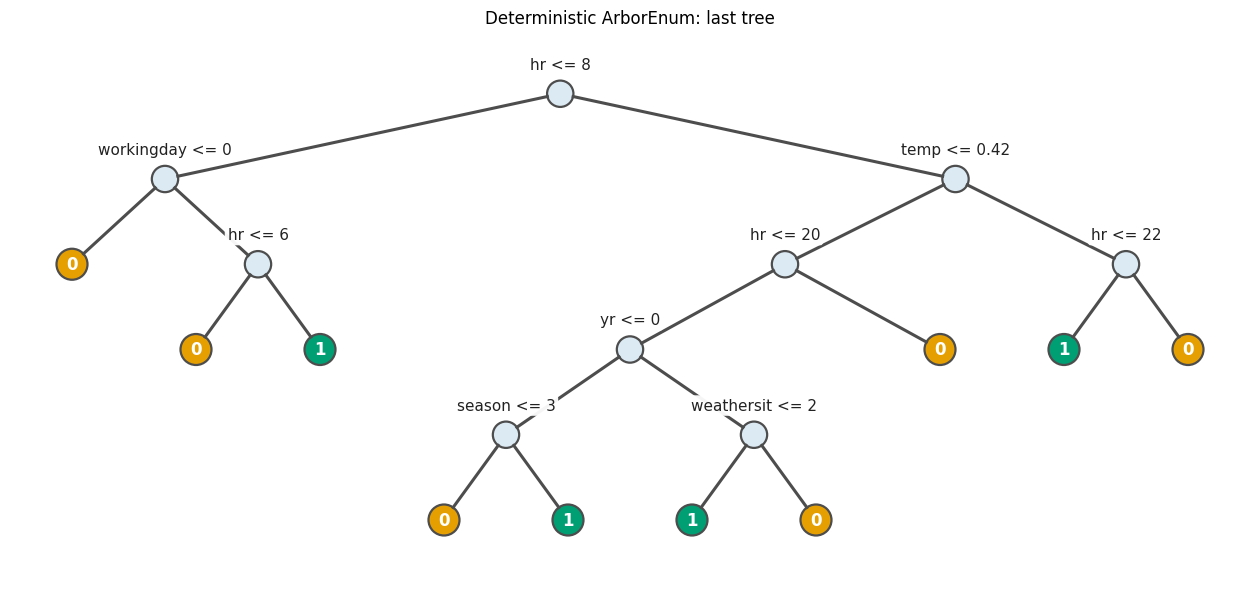


Anytime ArborEnum: first tree
----------------------------------------
tree index: 0
objective: 2784
normalized objective: 0.16019333678577594
number of leaves: 9
accuracy: 0.884861
first 10 predictions: [1, 0, 0, 0, 1, 1, 1, 0, 1, 1]


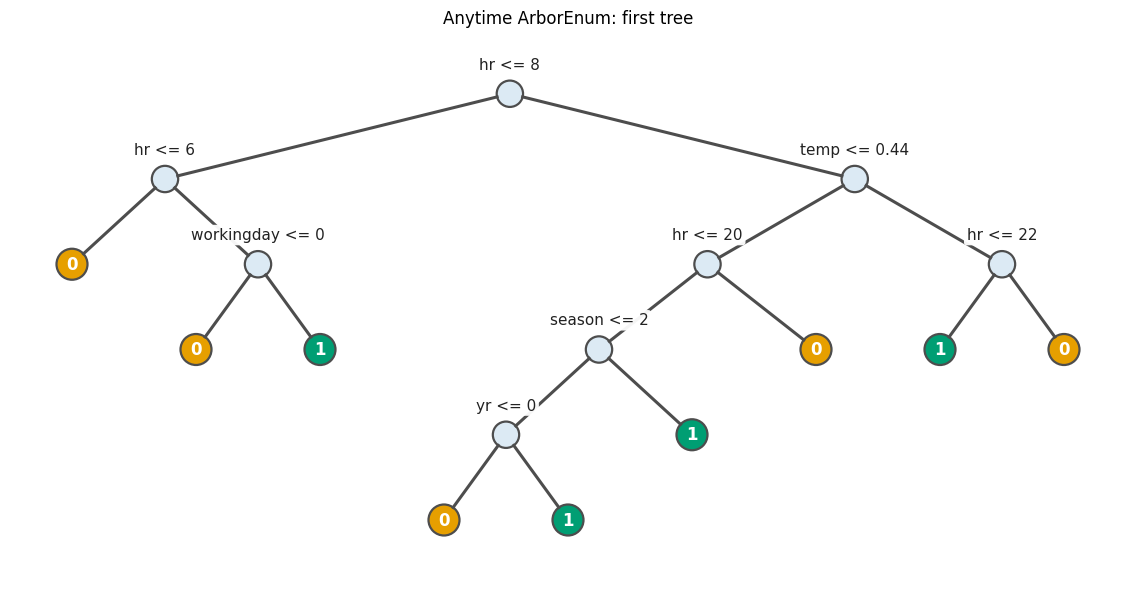


Anytime ArborEnum: last tree
----------------------------------------
tree index: 7663
objective: 2868
normalized objective: 0.16502675643017434
number of leaves: 9
accuracy: 0.880028
first 10 predictions: [1, 0, 0, 0, 1, 1, 1, 0, 1, 1]


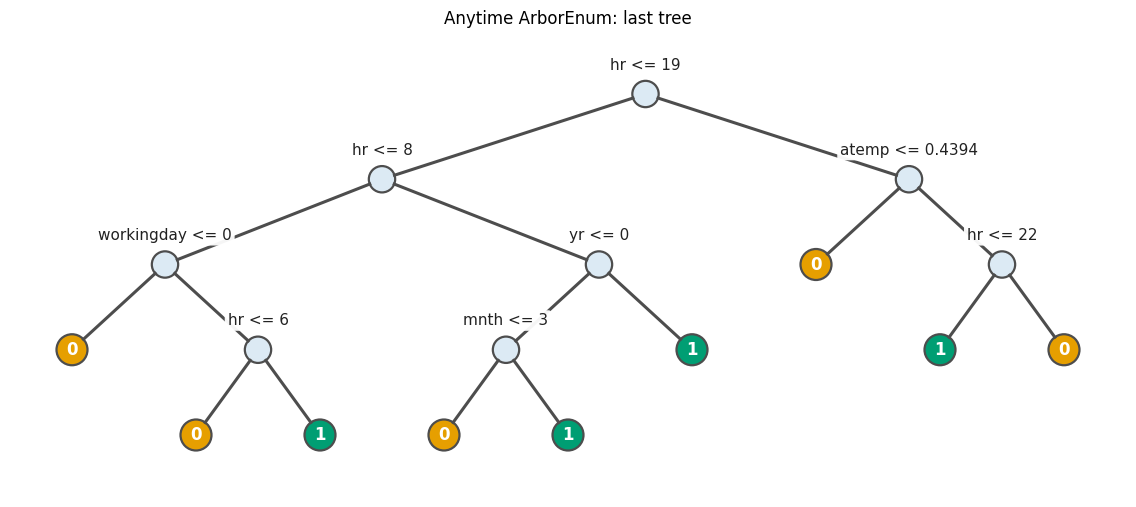

In [1]:
# Example showing the main deterministic and anytime ways to run ArborEnum.

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arborenum import ArborEnum


# ============================================================
# Data
# ============================================================

df = pd.read_csv("bike_processed.csv").sample(
    frac=1.0,
    replace=True,
    random_state=0,
).reset_index(drop=True)

y = df.pop("label").to_numpy(dtype=np.int32)
X = df


# ============================================================
# Deterministic algorithm
# ============================================================

deterministic_model = ArborEnum()

start = time.perf_counter()

# We recommend keeping all of these parameters for a high-quality approximation. 
# Only change lambda_reg, depth_budget, and rashomon_mult depending on what Rashomon set you want
# If you want an exact Rashomon set, use "continuous" for proxy_mode and lookahead_k = depth_budget-1
deterministic_model.fit(
    X,
    y,

    # Which thresholds the proxy algorithms may use: "continuous", "hybrid", or "binarized"
    # We recommend "hybrid" for strong approximation quality and speed.
    proxy_mode="hybrid",

    # Accuracy-interpretability trade-off. A split must reduce enough
    # misclassification error to justify the additional leaf penalty.
    lambda_reg=0.005,

    # Maximum allowed tree depth.
    depth_budget=5,

    # The Rashomon set contains trees whose objective is at most
    # approximately (1 + rashomon_mult) times the proxy objective.
    rashomon_mult=0.01,

    # Controls how close the proxy is to optimal:
    #   1: fast LicketySNIP-style proxy;
    #   depth_budget - 1 with proxy_mode="continuous":
    #       optimal continuous-feature proxy and exact enumeration;
    #   intermediate values trade runtime for approximation quality.
    lookahead_k=1,

    # None considers every available cutpoint.
    # A positive integer limits each continuous feature to that many cutpoints.
    max_number_thresholds_per_feature=None,

    # How subproblems are identified.
    # We recommend "hash" for a memory-efficient representation,
    # though "exact" bit-vector caching is also supported.
    key_mode="hash",
)

deterministic_elapsed = time.perf_counter() - start

print()
print("Deterministic ArborEnum")
print("-----------------------")
print("elapsed seconds:", f"{deterministic_elapsed:.2f}")
print(
    "minimum objective:",
    deterministic_model.get_min_objective(),
)
print(
    "number of trees:",
    deterministic_model.count_trees(),
)


# ============================================================
# Anytime algorithm
# ============================================================
#
# The anytime call uses the same main optimization settings.
# It adds early stopping, resource limits, proxy refinement,
# and optional Rashomon-multiplier expansion.
# ============================================================

anytime_model = ArborEnum()

start = time.perf_counter()

anytime_model.fit(
    X,
    y,

    # Use the anytime algorithm rather than the deterministic algorithm.
    early_stopping=True,

    # Same core settings as the deterministic run.
    proxy_mode="hybrid",
    lambda_reg=0.005,
    depth_budget=5,
    rashomon_mult=0.01,
    lookahead_k=1,
    max_number_thresholds_per_feature=None,
    key_mode="hash",

    # Use "on" for eventual convergence to the exact Rashomon set when
    # given enough resources. We recommend "auto" in practice so the
    # algorithm can decide whether further proxy refinement is worthwhile.
    proxy_refinement="auto",

    # After refining the graph for rashomon_mult=0.01, optionally
    # extend it toward a larger Rashomon multiplier.
    # Remove these two arguments when no extension is desired (or pass None for second_rashomon_mult).
    second_rashomon_mult=0.03,
    multiplier_step_size=0.0025,

    # Resource limits for the anytime algorithm.
    runtime_limit_seconds=600,
    memory_limit_mb=10000,
)

anytime_elapsed = time.perf_counter() - start

print()
print("Anytime ArborEnum")
print("-----------------")
print("elapsed seconds:", f"{anytime_elapsed:.2f}")
print(
    "minimum objective:",
    anytime_model.get_min_objective(),
)
print(
    "number of trees found in total:",
    anytime_model.count_trees(),
)
print(
    "trees within a 0.01 multiplier of the best tree found:",
    anytime_model.count_trees_within_mult(0.01),
)
print(
    "trees within a 0.03 multiplier of the best tree found:",
    anytime_model.count_trees_within_mult(0.03),
)


# ============================================================
# Inspect and plot the first and last trees
# ============================================================

for model, model_name in [
    (deterministic_model, "Deterministic ArborEnum"),
    (anytime_model, "Anytime ArborEnum"),
]:
    # trees are in sorted order of objective value, the first tree is the best tree
    number_of_trees = int(model.count_trees())

    tree_indices = [0]

    if number_of_trees > 1:
        tree_indices.append(number_of_trees - 1)

    for tree_index in tree_indices:
        tree_name = (
            "first tree"
            if tree_index == 0
            else "last tree"
        )

        objective, normalized_objective = (
            model.get_tree_objective(tree_index)
        )

        predictions = np.asarray(
            model.get_predictions(
                tree_index,
                X,
            ),
            dtype=np.int32,
        )

        accuracy = np.mean(predictions == y)

        print()
        print(f"{model_name}: {tree_name}")
        print("-" * 40)
        print("tree index:", tree_index)
        print("objective:", objective)
        print("normalized objective:", normalized_objective)
        print("number of leaves:", model.get_tree_num_leaves(tree_index))
        print("accuracy:", f"{accuracy:.6f}")
        print(
            "first 10 predictions:",
            predictions[:10].tolist(),
        )

        model.plot_tree(
            tree_index,
            title=f"{model_name}: {tree_name}",
            show=True,
        )

plt.show()


Extending anytime multiplier to Anytime Rashomon Importance Distribution
-----------------------------------------
elapsed seconds: 86.23
0.0125 with objective bound 2804
Extended minimum objective: 2769
Extending anytime multiplier to 0.015 with objective bound 2811
Extended minimum objective: 2769
Extending anytime multiplier to 0.0175 with objective bound 2817
Extended minimum objective: 2769
Extending anytime multiplier to 0.02 with objective bound 2824
Extended minimum objective: 2769
Extending anytime multiplier to 0.0225 with objective bound 2831
Extended minimum objective: 2769
Extending anytime multiplier to 0.025 with objective bound 2838
Extended minimum objective: 2769
Extending anytime multiplier to 0.0275 with objective bound 2845
Extended minimum objective: 2769
Extending anytime multiplier to 0.03 with objective bound 2852
Extended minimum objective: 2769
Further proxy refinement deemed too expensive for automatic mode.
Anytime minimum objective: 2769
Cache sizes - Gre

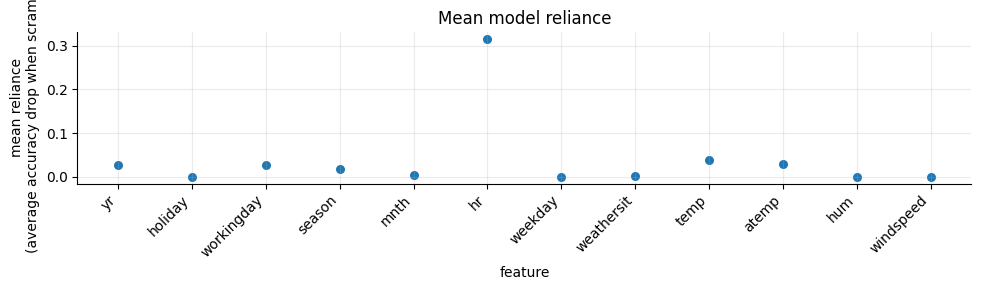

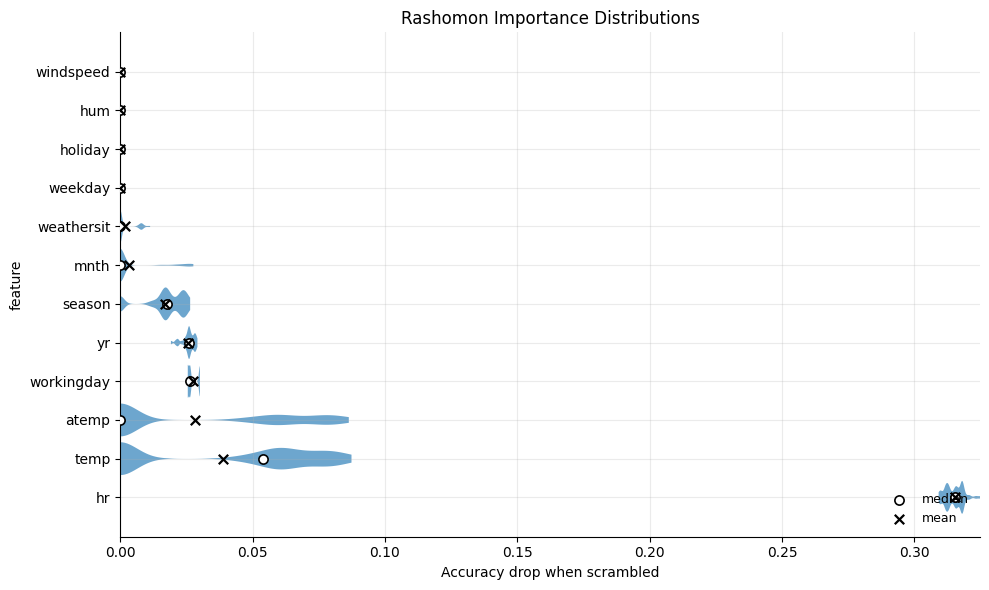

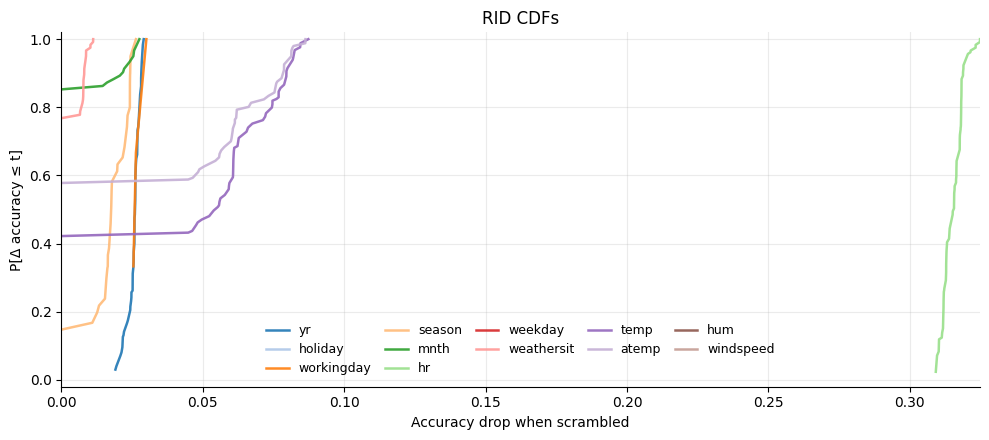

plotting: mnth vs. hr


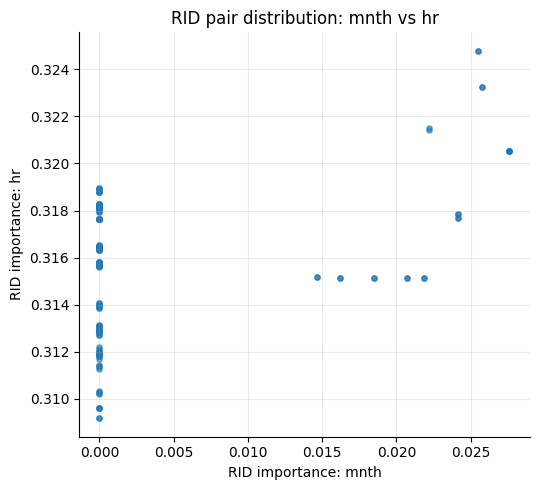

plotting: holiday vs. weekday


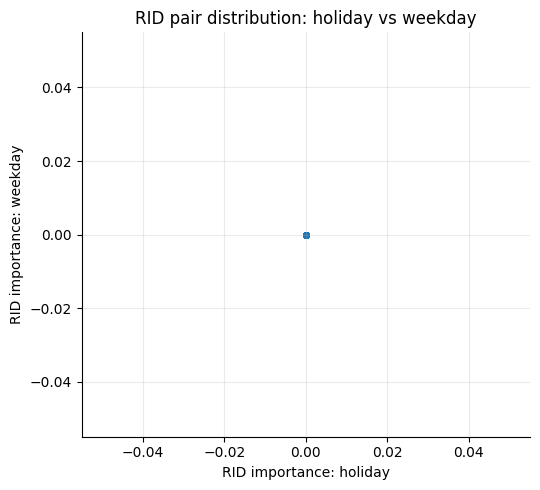

plotting: temp vs. hum


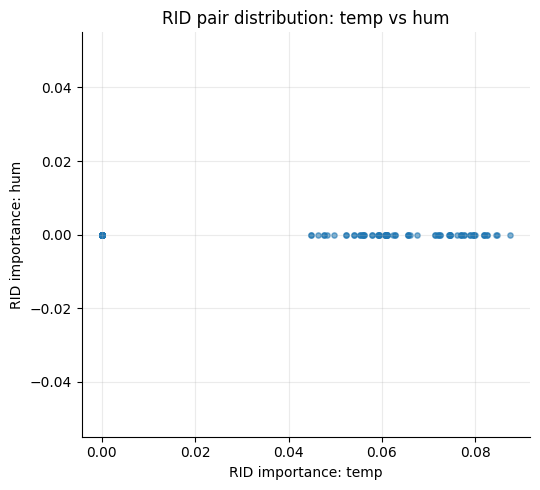

In [2]:


# ============================================================
# Rashomon Importance Distribution
# ============================================================
#
# This uses the same ArborEnum settings as above. It can be done with the anytime or deterministic algorithm.
# The only additional options are:
#   n_boot;
#   n_scramble_evals;
#   return_joint_samples.
# ============================================================

rid_model = ArborEnum()

start = time.perf_counter()

rid_result = rid_model.compute_rid(
    X,
    y,

    # Use anytime graph construction for RID.
    early_stopping=True,

    # Same ArborEnum settings as the anytime fit above.
    proxy_mode="hybrid",
    lambda_reg=0.005,
    depth_budget=5,
    rashomon_mult=0.01,
    lookahead_k=1,
    max_number_thresholds_per_feature=None,

    # Use "on" for eventual convergence to the exact Rashomon set when
    # given enough resources. We recommend "auto" in practice.
    proxy_refinement="auto",

    # Optionally refine the graph and then extend toward a larger
    # Rashomon multiplier. RID itself is computed over the trees within
    # the original rashomon_mult=0.01 bound.
    second_rashomon_mult=0.03,
    multiplier_step_size=0.0025,

    # Resource limits for anytime RID construction.
    runtime_limit_seconds=600,
    memory_limit_mb=10000,

    # Number of bootstrap repetitions used to estimate the RID.
    n_boot=3,

    # Number of feature permutations evaluated per feature in feature importance. higher provides a better estimate of the expectation, at the expense of runtime.
    n_scramble_evals=5,

    # Store aligned per-tree reliance samples. This is required for
    # pairwise RID plots and other joint-distribution analyses.
    return_joint_samples=True,
)

rid_elapsed = time.perf_counter() - start

print()
print("Anytime Rashomon Importance Distribution")
print("-----------------------------------------")
print("elapsed seconds:", f"{rid_elapsed:.2f}")


# ============================================================
# Plot the Rashomon Importance Distribution
# ============================================================

rid_model.rid_plot_mean(
    title="Mean model reliance",
    show=True,
)

rid_model.rid_plot_violin(
    title="Rashomon Importance Distributions",
    show=True,
)

rid_model.rid_plot_cdfs(
    title="RID CDFs",
    show=True,
)

# Plot a distribution of good trees over pairs of feature importances.
feature_pairs = [
    ("mnth", "hr"),
    ("holiday", "weekday"),
    ("temp", "hum"),
]

for feature_a, feature_b in feature_pairs:
    print(
        "plotting:",
        feature_a,
        "vs.",
        feature_b,
    )

    rid_model.rid_plot_pair(
        feature_a,
        feature_b,
        show=True,
    )

plt.show()

In [ ]:
# below are all of the interesting ways to run arborenum
# we cover the exact algorithm, approximate algorithms, and anytime algorithms (and also the Rashomon Importance Distribution for each case)
# we also show examples of increasing the rashomon budget over time and limiting to only x cut-points per feature.
# this cell is just more combinations than are present earlier.

import time

import numpy as np
import pandas as pd

from arborenum import ArborEnum

DATASET = "bike_processed.csv"

LAMBDA = 0.01
RASHOMON_MULT = 0.01
DEPTH = 4
LOOKAHEAD = 1

TIME_LIMIT = 600
MEMORY_LIMIT_MB = 10000
MAX_THRESHOLDS = 20

df = pd.read_csv(DATASET).sample(
    frac=1.0,
    replace=True,
    random_state=0,
).reset_index(drop=True)

y = df.pop("label").to_numpy(dtype=np.int32)
X = df.to_numpy(dtype=np.float64)


# deterministic algorithm with fully continuous proxies

model = ArborEnum()
start = time.perf_counter()

model.fit(
    X,
    y,
    early_stopping=False,
    proxy_mode="continuous",
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
)

elapsed = time.perf_counter() - start

print(
    "deterministic continuous: "
    f"time={elapsed:.2f}s, "
    f"trees={model.count_trees()}"
)

# optimal deterministic algorithm

model = ArborEnum()
start = time.perf_counter()

model.fit(
    X,
    y,
    early_stopping=False,
    proxy_mode="continuous",
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=DEPTH-1, # optimal proxy
)

elapsed = time.perf_counter() - start

print(
    "deterministic optimal rashomon set: "
    f"time={elapsed:.2f}s, "
    f"trees={model.count_trees()}"
)


# deterministic algorithm with hybrid proxy (LicketySNIP with the greedy subroutine restricted to xgboost splits)
model = ArborEnum()
start = time.perf_counter()

model.fit(
    X,
    y,
    early_stopping=False,
    proxy_mode="hybrid",
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
)

elapsed = time.perf_counter() - start

print(
    "deterministic hybrid: "
    f"time={elapsed:.2f}s, "
    f"trees={model.count_trees()}"
)


# deterministic with fully binarized proxies (using splits from xgboost)

model = ArborEnum()
start = time.perf_counter()

model.fit(
    X,
    y,
    early_stopping=False,
    proxy_mode="binarized",
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
)

elapsed = time.perf_counter() - start

print(
    "deterministic binarized: "
    f"time={elapsed:.2f}s, "
    f"trees={model.count_trees()}"
)


# anytime with fully continuous proxies

model = ArborEnum()
start = time.perf_counter()

model.fit(
    X,
    y,
    early_stopping=True,
    proxy_mode="continuous",
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
    runtime_limit_seconds=TIME_LIMIT,
    memory_limit_mb=MEMORY_LIMIT_MB,
)

elapsed = time.perf_counter() - start

print(
    "anytime continuous: "
    f"time={elapsed:.2f}s, "
    f"trees={model.count_trees()}"
)


# anytime with hybrid proxies

model = ArborEnum()
start = time.perf_counter()

model.fit(
    X,
    y,
    early_stopping=True,
    proxy_mode="hybrid",
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
    runtime_limit_seconds=TIME_LIMIT,
    memory_limit_mb=MEMORY_LIMIT_MB,
)

elapsed = time.perf_counter() - start

print(
    "anytime hybrid: "
    f"time={elapsed:.2f}s, "
    f"trees={model.count_trees()}"
)


# anytime with fully binarized proxies (the initial solve is over that binarization)

model = ArborEnum()
start = time.perf_counter()

model.fit(
    X,
    y,
    early_stopping=True,
    proxy_mode="binarized",
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
    runtime_limit_seconds=TIME_LIMIT,
    memory_limit_mb=MEMORY_LIMIT_MB,
)

elapsed = time.perf_counter() - start

print(
    "anytime binarized: "
    f"time={elapsed:.2f}s, "
    f"trees={model.count_trees()}"
)


# deterministic RID with hybrid proxies

model = ArborEnum()
start = time.perf_counter()

rid_deterministic = model.compute_rid(
    X,
    y,
    early_stopping=False,
    proxy_mode="hybrid",
    n_boot=3,
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
)

elapsed = time.perf_counter() - start

print(
    "deterministic RID hybrid: "
    f"time={elapsed:.2f}s, "
    f"features={len(rid_deterministic['mean_sub_mr'])}"
)


# anytime RID with hybrid proxies

model = ArborEnum()
start = time.perf_counter()

rid_anytime = model.compute_rid(
    X,
    y,
    early_stopping=True,
    proxy_mode="hybrid",
    n_boot=3,
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
    runtime_limit_seconds=TIME_LIMIT,
    memory_limit_mb=MEMORY_LIMIT_MB,
)

elapsed = time.perf_counter() - start

print(
    "anytime RID hybrid: "
    f"time={elapsed:.2f}s, "
    f"features={len(rid_anytime['mean_sub_mr'])}"
)


# anytime algorithm that extends the Rashomon multiplier
# starts at 0.01, refines to consider all thresholds, and then extends toward 0.03 in steps of 0.0025.
# ------------------------------------------------------------

model = ArborEnum()
start = time.perf_counter()

model.fit(
    X,
    y,
    early_stopping=True,
    proxy_mode="hybrid",
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    second_rashomon_mult=0.03,
    multiplier_step_size=0.0025,
    lookahead_k=LOOKAHEAD,
    runtime_limit_seconds=TIME_LIMIT,
    memory_limit_mb=MEMORY_LIMIT_MB,
)

elapsed = time.perf_counter() - start

print(
    "anytime hybrid with multiplier extension: "
    f"time={elapsed:.2f}s, "
    f"trees={model.count_trees()}"
)


# deterministic algorithm using at most 20 thresholds per feature (bucket features before applying optimization techniques)

model = ArborEnum()
start = time.perf_counter()

model.fit(
    X,
    y,
    early_stopping=False,
    proxy_mode="hybrid",
    max_number_thresholds_per_feature=MAX_THRESHOLDS,
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
)

elapsed = time.perf_counter() - start

print(
    "deterministic max 20 thresholds: "
    f"time={elapsed:.2f}s, "
    f"trees={model.count_trees()}"
)


# anytime algorithm using at most 20 thresholds per feature (bucket features before applying optimization techniques). the anytime algorithm will converge to a rashomon set over these buckets.


model = ArborEnum()
start = time.perf_counter()

model.fit(
    X,
    y,
    early_stopping=True,
    proxy_mode="hybrid",
    max_number_thresholds_per_feature=MAX_THRESHOLDS,
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
    runtime_limit_seconds=TIME_LIMIT,
    memory_limit_mb=MEMORY_LIMIT_MB,
)

elapsed = time.perf_counter() - start

print(
    "anytime max 20 thresholds: "
    f"time={elapsed:.2f}s, "
    f"trees={model.count_trees()}"
)


# deterministic RID with at most 20 thresholds per feature

model = ArborEnum()
start = time.perf_counter()

rid_deterministic_capped = model.compute_rid(
    X,
    y,
    early_stopping=False,
    proxy_mode="hybrid",
    max_number_thresholds_per_feature=MAX_THRESHOLDS,
    n_boot=3,
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
)

elapsed = time.perf_counter() - start

print(
    "deterministic RID max 20 thresholds: "
    f"time={elapsed:.2f}s, "
    f"features={len(rid_deterministic_capped['mean_sub_mr'])}"
)


# anytime RID with at most 20 thresholds per feature

model = ArborEnum()
start = time.perf_counter()

rid_anytime_capped = model.compute_rid(
    X,
    y,
    early_stopping=True,
    proxy_mode="hybrid",
    max_number_thresholds_per_feature=MAX_THRESHOLDS,
    n_boot=3,
    lambda_reg=LAMBDA,
    depth_budget=DEPTH,
    rashomon_mult=RASHOMON_MULT,
    lookahead_k=LOOKAHEAD,
    runtime_limit_seconds=TIME_LIMIT,
    memory_limit_mb=MEMORY_LIMIT_MB,
)

elapsed = time.perf_counter() - start

print(
    "anytime RID max 20 thresholds: "
    f"time={elapsed:.2f}s, "
    f"features={len(rid_anytime_capped['mean_sub_mr'])}"
)

Best objective: deterministic continuous: time=9.19s, trees=106
3378 (0.194373)
Objective bound: 3412
Minimum objective: 3378
Cache sizes - Greedy: 27995, Lickety: 133086, Trie: 131, Trie cache: ON
Best objective: deterministic optimal rashomon set: time=83.34s, trees=106
3378 (0.194373)
Objective bound: 3412
Minimum objective: 3378
Cache sizes - Greedy: 0, Lickety: 1435513, Trie: 131, Trie cache: ON
Best objective: 3378 (deterministic hybrid: time=4.07s, trees=106
0.194373)
Objective bound: 3412
Minimum objective: 3378
Cache sizes - Greedy: 159688, Lickety: 5119, Trie: 131, Trie cache: ON
Best objective: 3378 (deterministic binarized: time=3.41s, trees=106
0.194373)
Objective bound: 3412
Minimum objective: 3378
Cache sizes - Greedy: 21740, Lickety: 111511, Trie: 131, Trie cache: ON
Further proxy refinement deemed too expensive for automatic mode.
anytime continuous: time=9.54s, trees=106
Anytime minimum objective: 3378
Cache sizes - Greedy: 29208, Lickety: 136662, Trie: 0, Trie cache: